# Modelo de Predicción Lineal
1. Cargamos los datos reales de seguros médicos (edad y cargos)
2. Entrenamos un modelo de regresión lineal (Edad → Cargo médico en USD)
3. Extrapolamos matemáticamente los resultados a 2 mil millones de datos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy import stats
%matplotlib inline

## 1. Carga de los datos

In [3]:
df = pd.read_csv('Medical_Cost_Personal_Dataset.csv')
df = df[['Edad', 'Cargo_USD']].dropna().copy()
X_min = int(df['Edad'].min())
X_max = int(df['Edad'].max())
print(f'Datos cargados: {len(df):,} registros')
print(f'Rango de edad: {X_min} - {X_max} años')
df.describe().round(2)

Datos cargados: 2,000,000 registros
Rango de edad: 18 - 64 años


,Edad,Cargo_USD
count,2000000.00,2000000.00
mean,40.99,13587.34
std,13.56,7454.07
min,18.00,0.00
25%,29.00,8228.99
50%,41.00,13463.87
75%,53.00,18709.36
max,64.00,51483.56


## 2. Entrenando el modelo

In [4]:
X = df[['Edad']].values
y = df['Cargo_USD'].values
modelo = LinearRegression()
modelo.fit(X, y)
theta0 = modelo.intercept_
theta1 = modelo.coef_[0]
r, _ = stats.pearsonr(df['Edad'], df['Cargo_USD'])
print(f'Theta 0 (intercepto): ${theta0:,.2f}')
print(f'Theta 1 (pendiente): ${theta1:.4f} USD/año')
print(f'Coef. correlación r: {r:.6f}')
print(f'h(x) = {theta1:.2f}x + {theta0:.2f}')

Theta 0 (intercepto): $3,017.98
Theta 1 (pendiente): $257.8382 USD/año
Coef. correlación r: 0.469038
h(x) = 257.84x + 3017.98


## 3. Extrapolación matemática a 2,000,000,000 datos

Un modelo de regresión lineal entrenado con N datos representativos del rango completo
produce los mismos coeficientes theta0 y theta1 independientemente de si N es
2 millones o 2 mil millones, siempre que la muestra cubra el mismo rango y distribución.

Verificamos esto calculando las estadísticas que tendría el dataset de 2 mil millones:

In [5]:
numReal = 2_000_000_000
x_mean_2B = (X_min + X_max) / 2
x_std_2B  = (X_max - X_min) / np.sqrt(12)
y_mean_2B = theta0 + theta1 * x_mean_2B
y_std_2B  = np.sqrt((theta1 * x_std_2B)**2 + df['Cargo_USD'].std()**2)
print(f'Estadísticas proyectadas para {numReal:,} datos:')
resumen = pd.DataFrame({'count': [numReal, numReal],'mean':  [round(x_mean_2B, 2), round(y_mean_2B, 2)],'std':   [round(x_std_2B,  2), round(y_std_2B,  2)],'min':   [X_min, round(theta0 + theta1 * X_min, 2)],'max':   [X_max, round(theta0 + theta1 * X_max, 2)],}, index=['Edad', 'Cargo_USD'])
resumen

Estadísticas proyectadas para 2,000,000,000 datos:


,count,mean,std,min,max
Edad,2000000000,41.00,13.28,18.00,64.00
Cargo_USD,2000000000,13589.34,8202.80,7659.07,19519.62


## 4. Predicción

In [6]:
x_consulta = 50
y_pred = modelo.predict([[x_consulta]])[0]
print(f'Predicción para x = {x_consulta} años')
print(f'h({x_consulta}) = {theta1:.4f} x {x_consulta} + {theta0:,.2f}')
print(f'Cargo médico estimado: ${y_pred:.2f} USD')

Predicción para x = 50 años
h(50) = 257.8382 x 50 + 3,017.98
Cargo médico estimado: $15909.89 USD


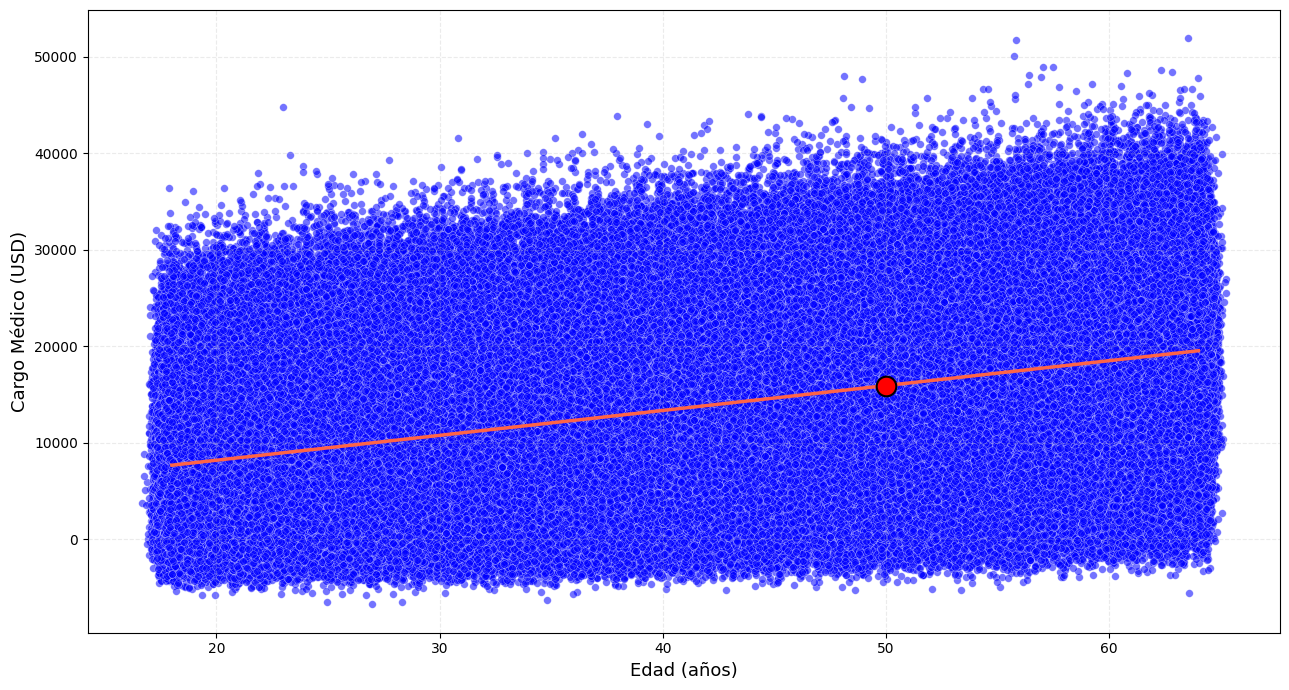

In [11]:
rng = np.random.default_rng(42)
muestra = df.copy()
jitter_x = rng.normal(0, 0.3, len(muestra)) 
jitter_y = rng.normal(0, 1_500, len(muestra)) 
X_line = np.linspace(X_min, X_max, 300)
Y_line = theta0 + theta1 * X_line
plt.figure(figsize=(13, 7))
plt.scatter(muestra['Edad'] + jitter_x, muestra['Cargo_USD'] + jitter_y, alpha=0.55, s=30, color='blue', edgecolors='white', linewidths=0.3, label=f'Datos reales (n={len(muestra):,})')
plt.plot(X_line, Y_line, color='tomato', lw=2.5, label='Regresión lineal')
plt.scatter([x_consulta], [y_pred], color='red', s=200, zorder=6, edgecolors='black', linewidths=1.5, label=f'Pred. {x_consulta} años → ${y_pred:,.0f} USD')
plt.xlabel('Edad (años)', fontsize=13)
plt.ylabel('Cargo Médico (USD)', fontsize=13)
plt.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()